<a href="https://colab.research.google.com/github/dave-nandini/retail-sales-analytics-/blob/main/Retail_Sales_Data_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Current directory:", os.getcwd())
print("Files in current directory:")
print(os.listdir())

df = pd.read_csv('/content/Superstore.csv', encoding='cp1252')

df.head()

print("Shape:", df.shape)

print("Columns:")
print(df.columns.tolist())
df.info()
print("Missing values:")
print(df.isnull().sum())

Current directory: /content
Files in current directory:
['.config', '.ipynb_checkpoints', 'Superstore.csv', 'sample_data']
Shape: (9994, 21)
Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 

In [9]:
#Create a backup of the raw data
df_clean = df.copy()

print("Original shape:", df.shape)
print("Working dataset shape:", df_clean.shape)

Original shape: (9994, 21)
Working dataset shape: (9994, 21)


# **CLEANING DATA**

In [ ]:
#CHECKING MISSING VALUES
missing_values = df_clean.isnull().sum()

print(missing_values)

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [ ]:
#DUPLICATE VALUES
duplicate_count = df_clean.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [ ]:
#CONVERT DATES FROM OBJECT TO DATE
df_clean["Order Date"] = pd.to_datetime(df_clean["Order Date"])
df_clean["Ship Date"] = pd.to_datetime(df_clean["Ship Date"])

#THEN CHECK
print(df_clean[["Order Date", "Ship Date"]].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [ ]:
#Check numerical columns
df_clean[["Sales", "Quantity", "Discount", "Profit"]].describe()

#CHECK FOR NEGATIVE VALUES
print("Negative Sales:", (df_clean["Sales"] < 0).sum())
print("Negative Quantity:", (df_clean["Quantity"] < 0).sum())
print("Negative Discount:", (df_clean["Discount"] < 0).sum())
print("Negative Profit:", (df_clean["Profit"] < 0).sum())

Negative Sales: 0
Negative Quantity: 0
Negative Discount: 0
Negative Profit: 1871


In [ ]:
#Check categorical columns
print("Ship Modes:")
print(df_clean["Ship Mode"].unique())

print("\nSegments:")
print(df_clean["Segment"].unique())

print("\nRegions:")
print(df_clean["Region"].unique())

print("\nCategories:")
print(df_clean["Category"].unique())

Ship Modes:
['Second Class' 'Standard Class' 'First Class' 'Same Day']

Segments:
['Consumer' 'Corporate' 'Home Office']

Regions:
['South' 'West' 'Central' 'East']

Categories:
['Furniture' 'Office Supplies' 'Technology']


In [ ]:
#Check number of unique customers/products
print("Unique Customers:", df_clean["Customer ID"].nunique())
print("Unique Products:", df_clean["Product ID"].nunique())
print("Unique Orders:", df_clean["Order ID"].nunique())
print("Unique Cities:", df_clean["City"].nunique())
print("Unique States:", df_clean["State"].nunique())

Unique Customers: 793
Unique Products: 1862
Unique Orders: 5009
Unique Cities: 531
Unique States: 49


In [ ]:
#Create Shipping Days
df_clean["Shipping_Days"] = (
    df_clean["Ship Date"] - df_clean["Order Date"]
).dt.days

df_clean[["Order Date", "Ship Date", "Shipping_Days"]].head()

,Order Date,Ship Date,Shipping_Days
0,2016-11-08,2016-11-11,3
1,2016-11-08,2016-11-11,3
2,2016-06-12,2016-06-16,4
3,2015-10-11,2015-10-18,7
4,2015-10-11,2015-10-18,7


In [ ]:
#Create time-based features
df_clean["Year"] = df_clean["Order Date"].dt.year
df_clean["Month"] = df_clean["Order Date"].dt.month
df_clean["Month_Name"] = df_clean["Order Date"].dt.month_name
df_clean["Quarter"] = df_clean["Order Date"].dt.quarter
df_clean["Day_of_Week"] = df_clean["Order Date"].dt.day_name()
df_clean["Is_Weekend"] = df_clean["Order Date"].dt.dayofweek >= 5



In [ ]:
#Create Profit Margin
df_clean["Profit_Margin"] = np.where(
    df_clean["Sales"] != 0,
    (df_clean["Profit"] / df_clean["Sales"]) * 100,
    0
)

#check
df_clean[[
    "Sales",
    "Profit",
    "Profit_Margin"
]].head()

,Sales,Profit,Profit_Margin
0,261.9600,41.9136,16.00
1,731.9400,219.5820,30.00
2,14.6200,6.8714,47.00
3,957.5775,-383.0310,-40.00
4,22.3680,2.5164,11.25


In [10]:
#CHECK NEW DATASET
print("Original columns:", len(df.columns))
print("New columns:", len(df_clean.columns))

Original columns: 21
New columns: 21


In [11]:
#FINAL CHECK
print("Dataset Shape:", df_clean.shape)

print("\nMissing Values:")
print(df_clean.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df_clean.duplicated().sum())

print("\nData Types:")
print(df_clean.dtypes)

Dataset Shape: (9994, 21)

Missing Values:
0

Duplicate Rows:
0

Data Types:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [12]:
#SAVE CLEANED DATASET
df_clean.to_csv(
    "/content/Superstore_Cleaned.csv",
    index=False
)

import os

print(os.path.exists("/content/Superstore_Cleaned.csv"))





True


# **EDA-Exploratory Data Analysis**

In [16]:
#EDA-Exploratory Data Analysis

#Load the cleaned dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    "/content/Superstore_Cleaned.csv",

)

df.head()

df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 28 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [17]:
#Understand the overall business
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()
total_products = df["Product ID"].nunique()
total_quantity = df["Quantity"].sum()

print("Total Sales:", round(total_sales,2))
print("Total Profit:", round(total_profit,2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Total Products:", total_products)
print("Total Quantity:", total_quantity)


Total Sales: 2297200.86
Total Profit: 286397.02
Total Orders: 5009
Total Customers: 793
Total Products: 1862
Total Quantity: 37873


In [18]:
#Calculate Average Order Value
average_order_value = total_sales / total_orders
print("Average Order Value:", round(average_order_value,2))

#CALCULATE OVERALL PROFIT MARGIN
overall_profit_margin = (total_profit / total_sales) * 100

print("Overall Profit Margin:", round(overall_profit_margin, 2), "%")

Average Order Value: 458.61
Overall Profit Margin: 12.47 %


Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


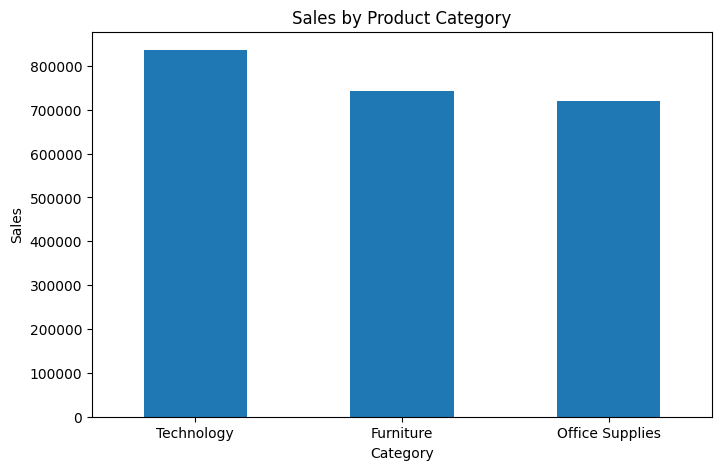

In [19]:
#CALCULATE SALES BY CATEGORY

category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(category_sales)

plt.figure(figsize=(8, 5))

category_sales.plot(kind="bar")

plt.title("Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=0)

plt.show()

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


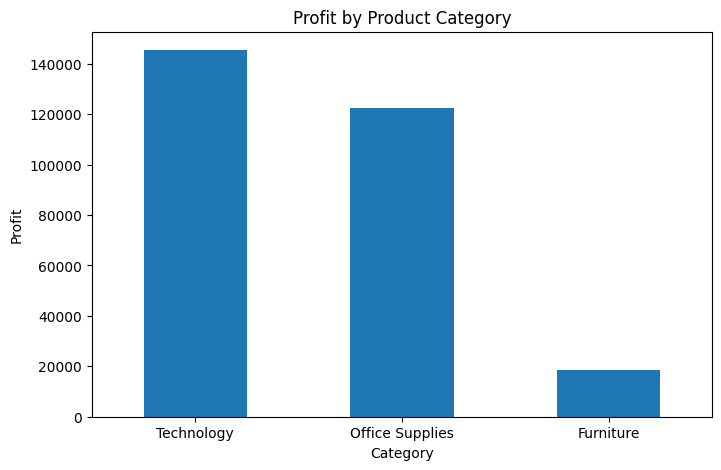

In [20]:
#Profit by Category
category_profit = (
    df.groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

print(category_profit)

plt.figure(figsize=(8, 5))

category_profit.plot(kind="bar")

plt.title("Profit by Product Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.xticks(rotation=0)

plt.show()

                       Sales       Profit
Category                                 
Furniture        741999.7953   18451.2728
Office Supplies  719047.0320  122490.8008
Technology       836154.0330  145454.9481


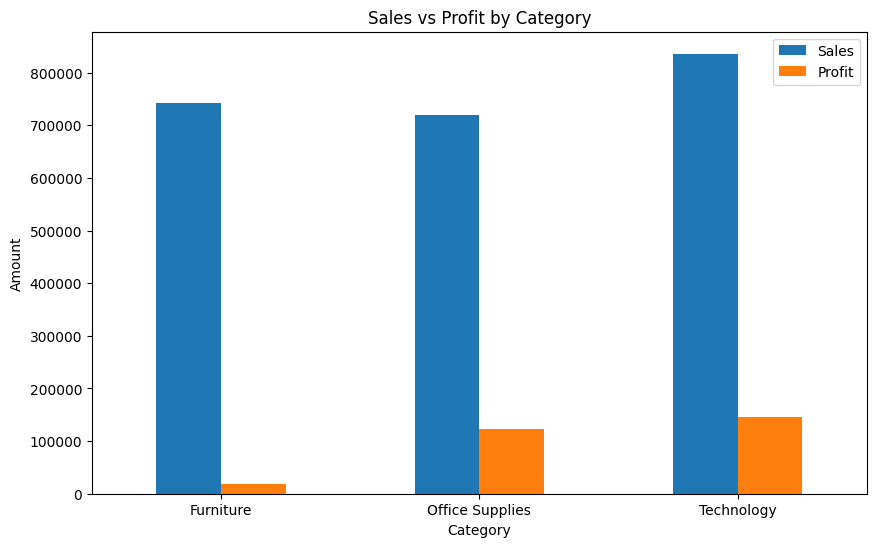

In [21]:
#Sales vs Profit by Category
category_performance = df.groupby("Category")[["Sales", "Profit"]].sum()

print(category_performance)

category_performance.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Sales vs Profit by Category")
plt.xlabel("Category")
plt.ylabel("Amount")
plt.xticks(rotation=0)

plt.show()

Sub-Category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Furnishings     91705.1640
Paper           78479.2060
Supplies        46673.5380
Art             27118.7920
Envelopes       16476.4020
Labels          12486.3120
Fasteners        3024.2800
Name: Sales, dtype: float64


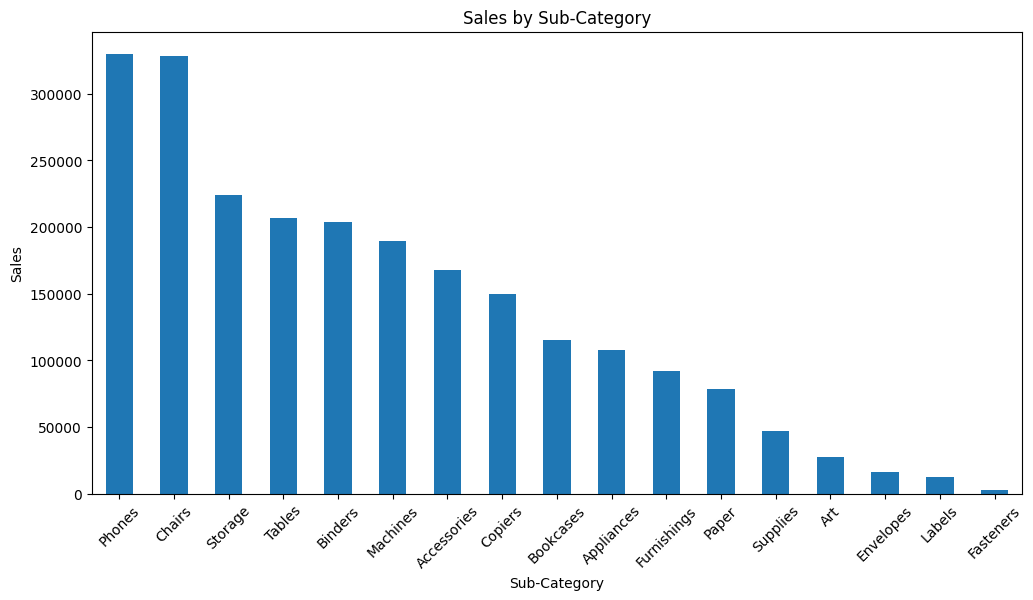

Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          34053.5693
Binders        30221.7633
Chairs         26590.1663
Storage        21278.8264
Appliances     18138.0054
Furnishings    13059.1436
Envelopes       6964.1767
Art             6527.7870
Labels          5546.2540
Machines        3384.7569
Fasteners        949.5182
Supplies       -1189.0995
Bookcases      -3472.5560
Tables        -17725.4811
Name: Profit, dtype: float64


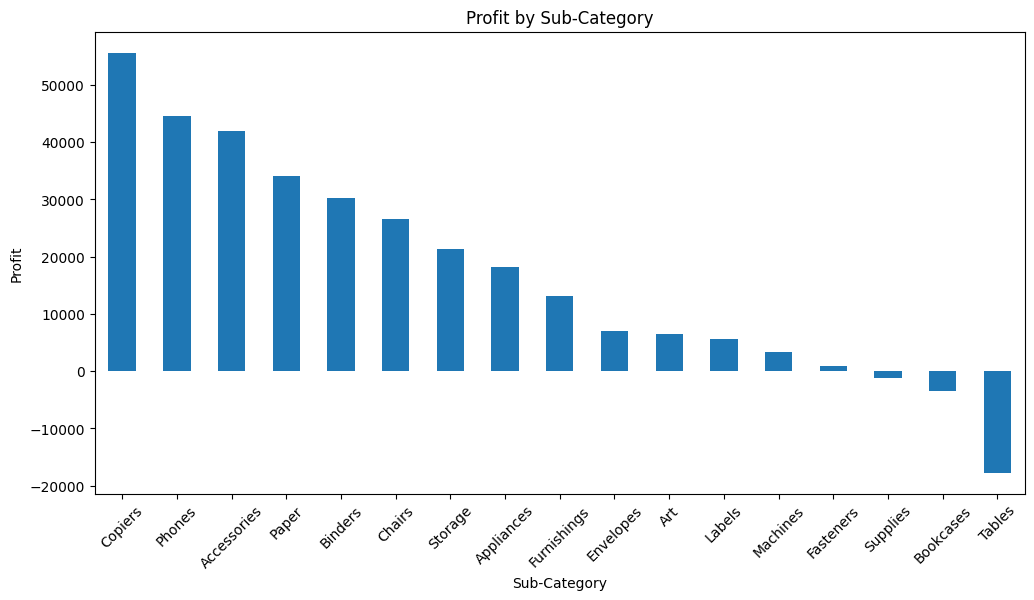

In [22]:
#Sub-Category Analysis
#SALES
subcategory_sales = (
    df.groupby("Sub-Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(subcategory_sales)

plt.figure(figsize=(12, 6))

subcategory_sales.plot(kind="bar")

plt.title("Sales by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Sales")
plt.xticks(rotation=45)

plt.show()

#PROFIT

subcategory_profit = (
    df.groupby("Sub-Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

print(subcategory_profit)

plt.figure(figsize=(12, 6))

subcategory_profit.plot(kind="bar")

plt.title("Profit by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Profit")
plt.xticks(rotation=45)

plt.show()

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


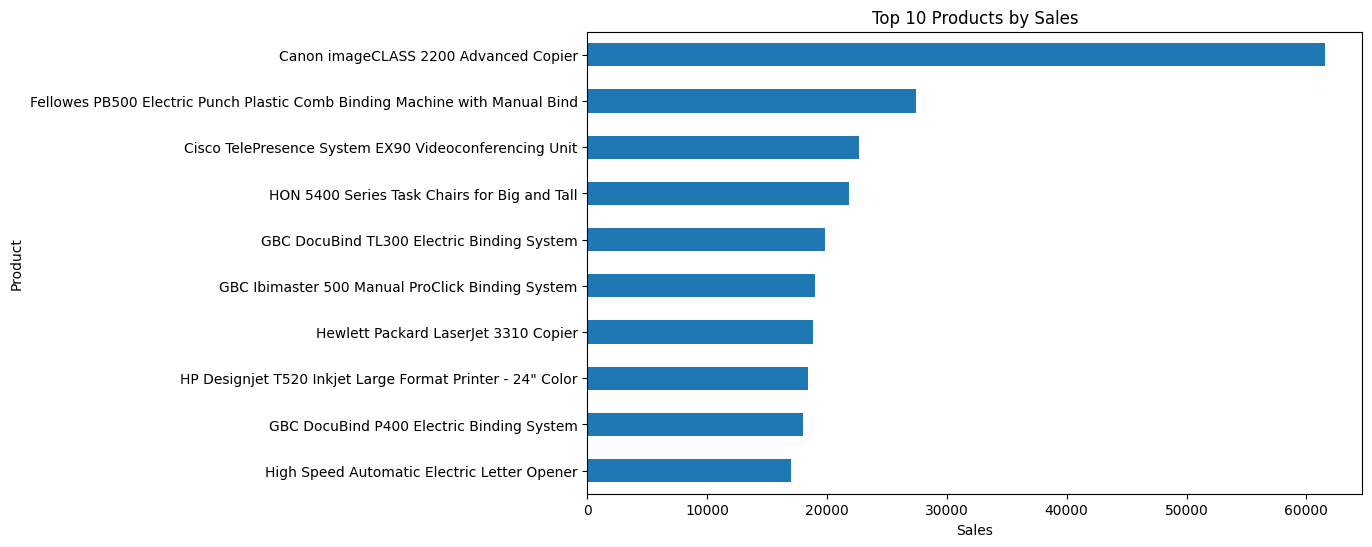

In [23]:
#Find the Top 10 Products
top_products_sales = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products_sales)

plt.figure(figsize=(10, 6))

top_products_sales.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")

plt.show()

Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64


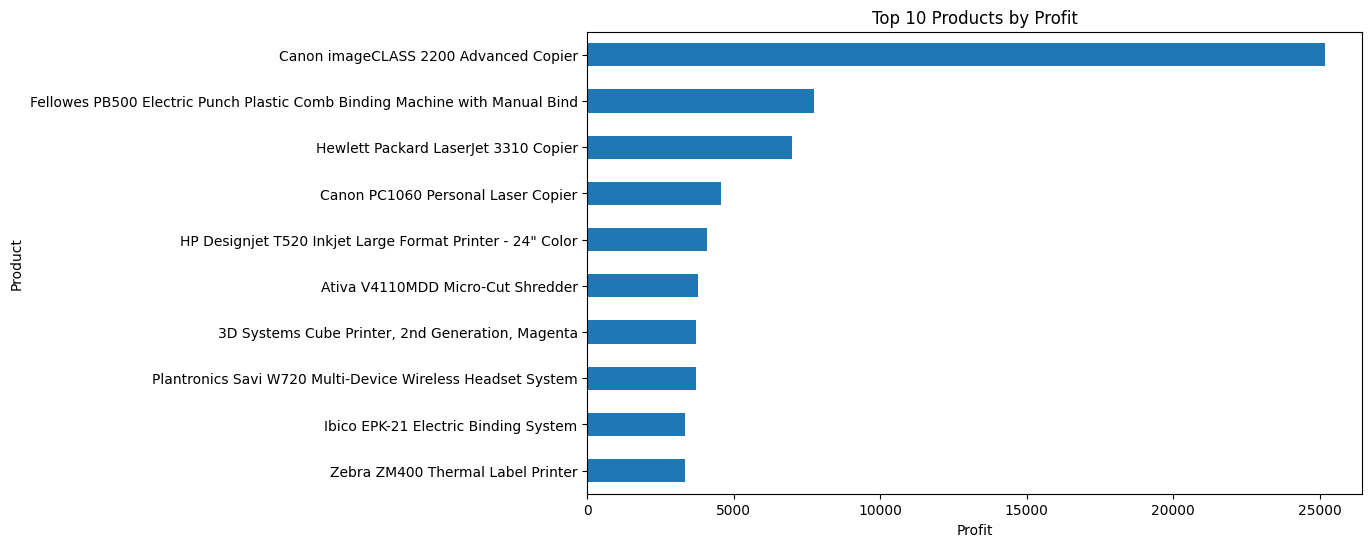

In [24]:
#Find the Top 10 Most Profitable Products
top_products_profit = (
    df.groupby("Product Name")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products_profit)

plt.figure(figsize=(10, 6))

top_products_profit.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Profit")
plt.xlabel("Profit")
plt.ylabel("Product")

plt.show()

Product Name
Cubify CubeX 3D Printer Double Head Print                                      -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                                      -4589.9730
Cubify CubeX 3D Printer Triple Head Print                                      -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases                       -2876.1156
Bush Advantage Collection Racetrack Conference Table                           -1934.3976
GBC DocuBind P400 Electric Binding System                                      -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit                          -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                             -1299.1836
Balt Solid Wood Round Tables                                                   -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables              -1148.4375
Riverside Furniture Oval Coffee Table, Oval End Table, End Table with Drawer   -1147.40

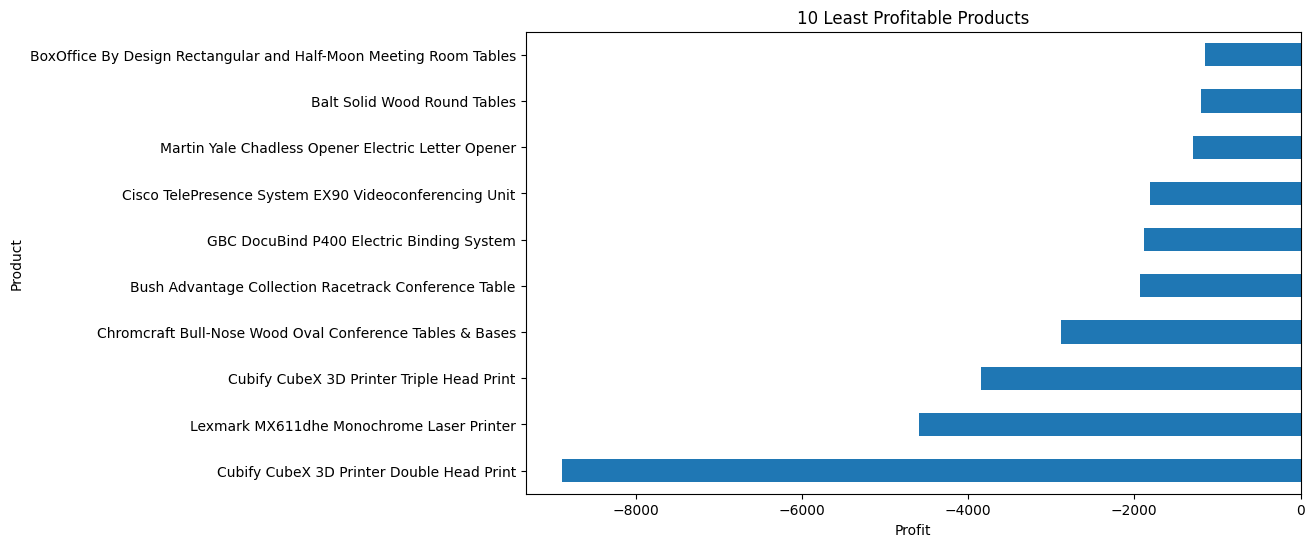

In [29]:
#LOSS MAKING PRODUCTS
product_profit = (
    df.groupby("Product Name")["Profit"]
    .sum()
    .sort_values()
)

loss_making_products = product_profit[product_profit < 0]

print(loss_making_products.head(20))

worst_products = product_profit.head(10)
print(worst_products)

plt.figure(figsize=(10, 6))

worst_products.sort_values().plot(kind="barh")

plt.title("10 Least Profitable Products")
plt.xlabel("Profit")
plt.ylabel("Product")

plt.show()

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


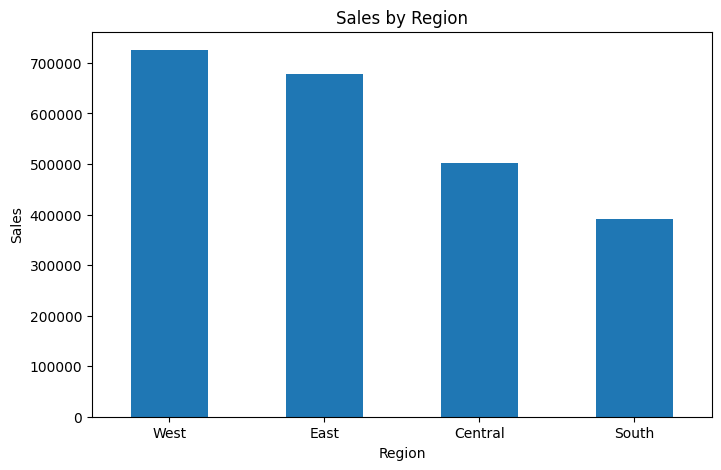

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

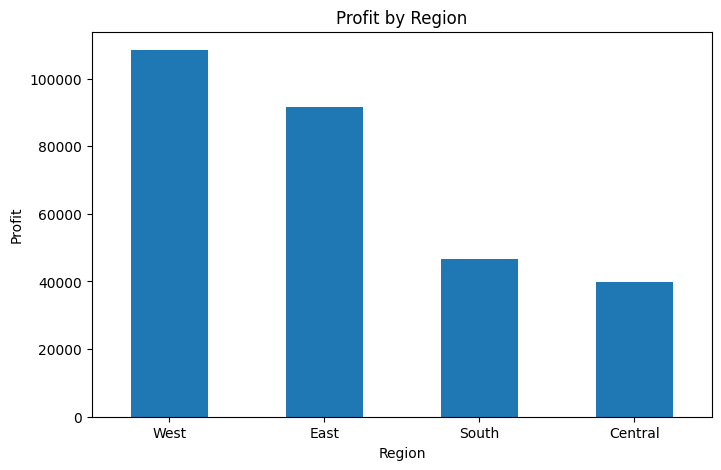

In [31]:
#Regional Analysis
#sales
region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(region_sales)

plt.figure(figsize=(8, 5))

region_sales.plot(kind="bar")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.xticks(rotation=0)

plt.show()

#profit
region_profit=(
    df.groupby("Region")["Profit"]
    .sum()
    .sort_values(ascending=False)
)
print(region_profit)

plt.figure(figsize=(8, 5))

region_profit.plot(kind="bar")

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.xticks(rotation=0)

plt.show

State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: Sales, dtype: float64


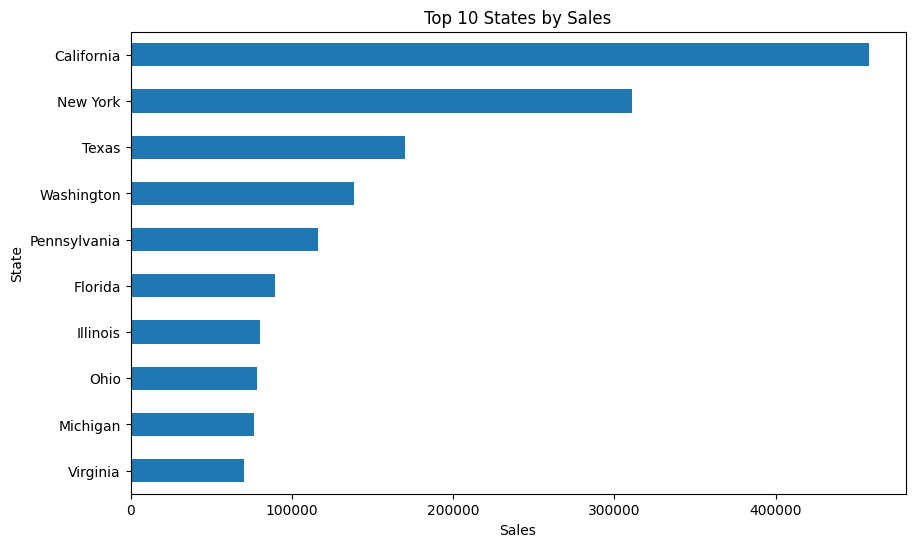

In [32]:
#State-Level Analysis
state_sales = (
    df.groupby("State")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(state_sales.head(10))

plt.figure(figsize=(10, 6))

state_sales.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 States by Sales")
plt.xlabel("Sales")
plt.ylabel("State")

plt.show()

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64
Segment
Consumer       134119.2092
Corporate       91979.1340
Home Office     60298.6785
Name: Profit, dtype: float64


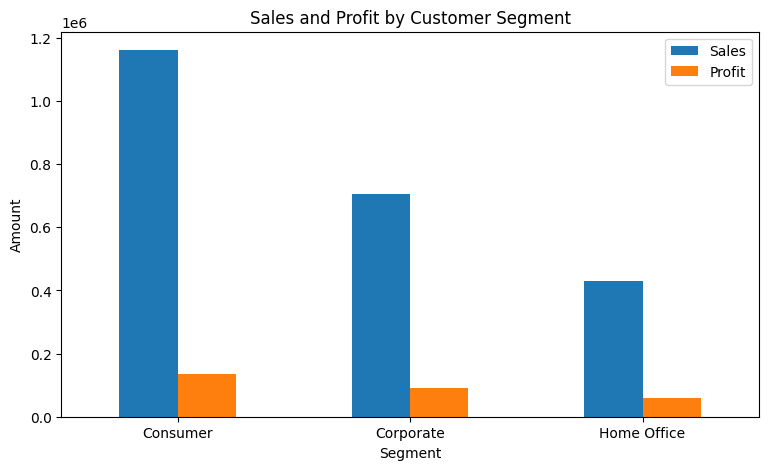

In [33]:
#Customer Segment Analysis
#sales
segment_sales = (
    df.groupby("Segment")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(segment_sales)

#profit

segment_profit = (
    df.groupby("Segment")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

print(segment_profit)

segment_performance = df.groupby("Segment")[["Sales", "Profit"]].sum()

segment_performance.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Sales and Profit by Customer Segment")
plt.ylabel("Amount")
plt.xticks(rotation=0)

plt.show()



Order Date
2014-01     14236.8950
2014-02      4519.8920
2014-03     55691.0090
2014-04     28295.3450
2014-05     23648.2870
2014-06     34595.1276
2014-07     33946.3930
2014-08     27909.4685
2014-09     81777.3508
2014-10     31453.3930
2014-11     78628.7167
2014-12     69545.6205
2015-01     18174.0756
2015-02     11951.4110
2015-03     38726.2520
2015-04     34195.2085
2015-05     30131.6865
2015-06     24797.2920
2015-07     28765.3250
2015-08     36898.3322
2015-09     64595.9180
2015-10     31404.9235
2015-11     75972.5635
2015-12     74919.5212
2016-01     18542.4910
2016-02     22978.8150
2016-03     51715.8750
2016-04     38750.0390
2016-05     56987.7280
2016-06     40344.5340
2016-07     39261.9630
2016-08     31115.3743
2016-09     73410.0249
2016-10     59687.7450
2016-11     79411.9658
2016-12     96999.0430
2017-01     43971.3740
2017-02     20301.1334
2017-03     58872.3528
2017-04     36521.5361
2017-05     44261.1102
2017-06     52981.7257
2017-07     45264.4160


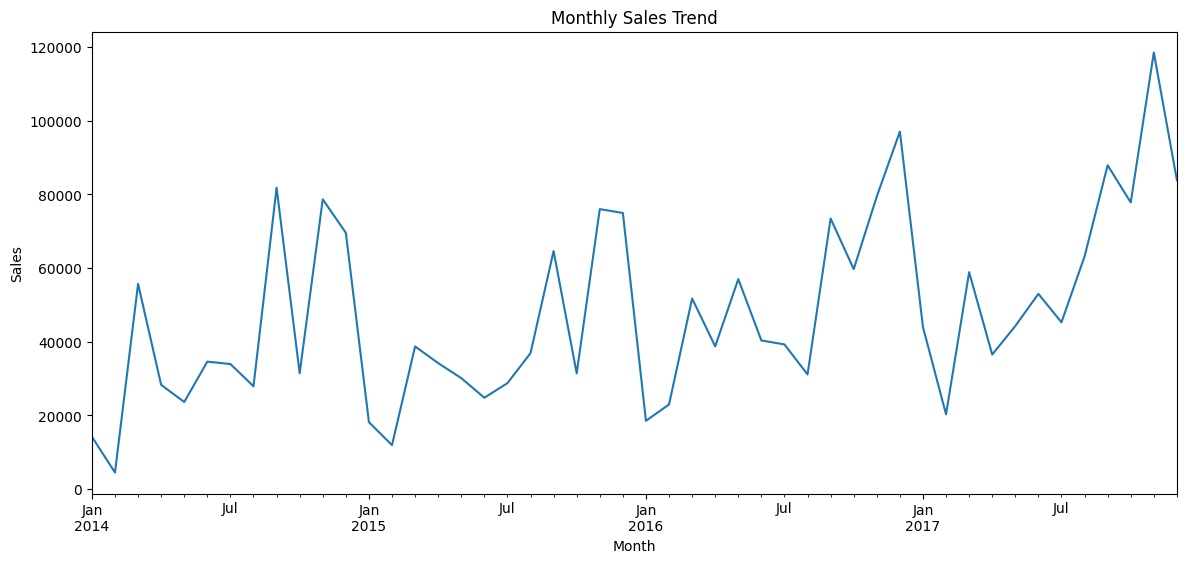

In [35]:
#TIME SERIES ANALYSIS
monthly_sales = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Sales"]
    .sum()
)
print(monthly_sales)

plt.figure(figsize=(14, 6))

monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64


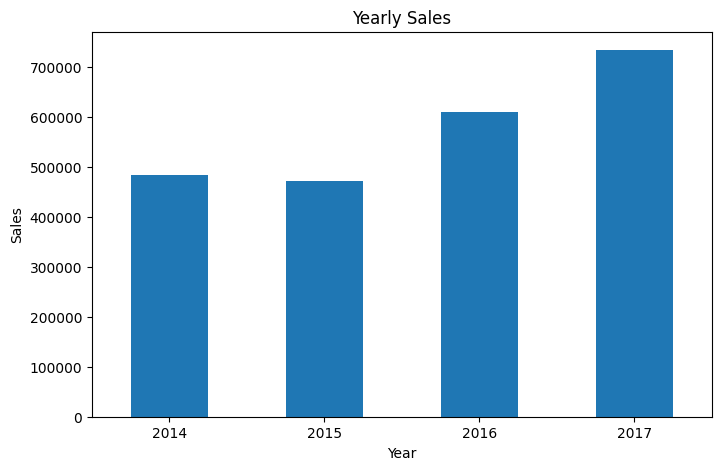

Year
2014    49543.9741
2015    61618.6037
2016    81795.1743
2017    93439.2696
Name: Profit, dtype: float64


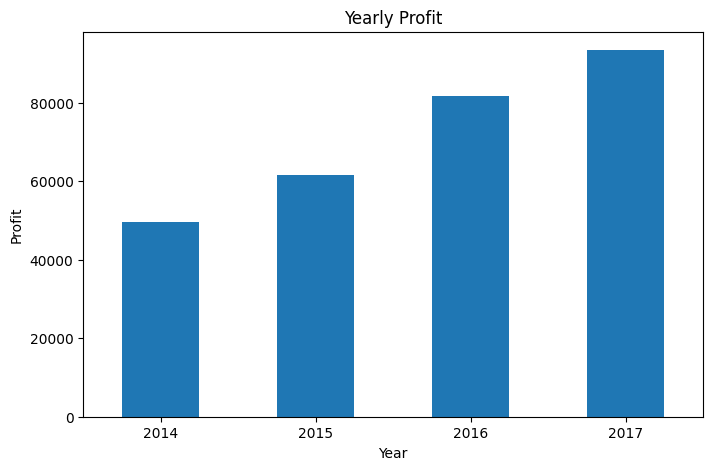

In [36]:
#YEARLY SALES COMPARISONS
#SALES
yearly_sales = (
    df.groupby("Year")["Sales"]
    .sum()
)

print(yearly_sales)

plt.figure(figsize=(8, 5))

yearly_sales.plot(kind="bar")

plt.title("Yearly Sales")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.xticks(rotation=0)

plt.show()

#PROFIT
yearly_profit = (
    df.groupby("Year")["Profit"]
    .sum()
)

print(yearly_profit)

plt.figure(figsize=(8, 5))

yearly_profit.plot(kind="bar")

plt.title("Yearly Profit")
plt.xlabel("Year")
plt.ylabel("Profit")
plt.xticks(rotation=0)

plt.show()

Discount
0.00     66.900292
0.10     96.055074
0.15     27.288298
0.20     24.702572
0.30    -45.679636
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -101.796797
Name: Profit, dtype: float64


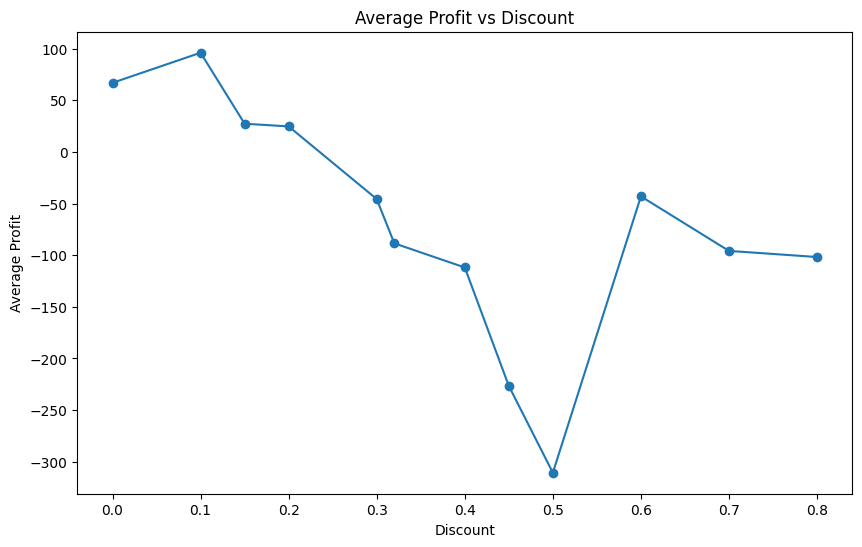

In [38]:
#Discount vs Profit
df[["Discount", "Profit"]].describe()

discount_profit = (
    df.groupby("Discount")["Profit"]
    .mean()
    .sort_index()
)

print(discount_profit)

plt.figure(figsize=(10, 6))

discount_profit.plot(kind="line", marker="o")

plt.title("Average Profit vs Discount")
plt.xlabel("Discount")
plt.ylabel("Average Profit")

plt.show()

0       3
1       3
2       4
3       7
4       7
       ..
9989    2
9990    5
9991    5
9992    5
9993    5
Name: Shipping_Days, Length: 9994, dtype: int64
Average Shipping Days: 3.96


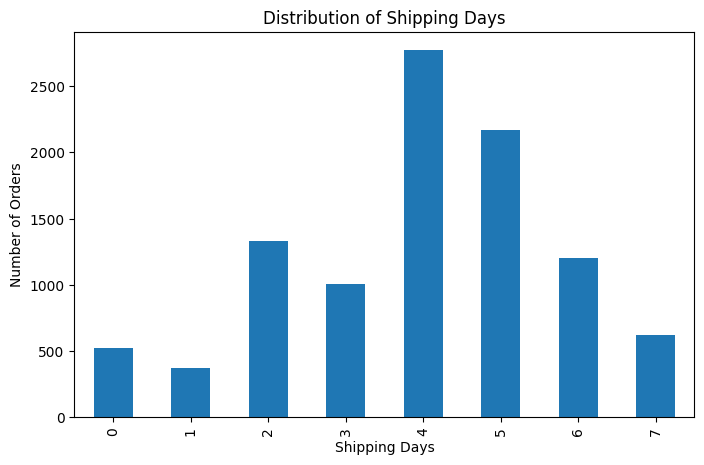

In [43]:
#SHIPPING ANALYSIS
# Ensure 'Shipping_Days' is calculated if it's not present in the loaded df
# This column was created in df_clean but might not have been saved to Superstore_Cleaned.csv
df["Shipping_Days"] = (df["Ship Date"] - df["Order Date"]).dt.days
print(df["Shipping_Days"])

print("Average Shipping Days:",
      round(df["Shipping_Days"].mean(), 2))


plt.figure(figsize=(8, 5))

df["Shipping_Days"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Shipping Days")
plt.xlabel("Shipping Days")
plt.ylabel("Number of Orders")

plt.show()

Shipping_Days
0    29.645411
1    20.436929
2    39.818676
3    26.742208
4    25.643394
5    27.078471
6    27.660821
7    32.740494
Name: Profit, dtype: float64


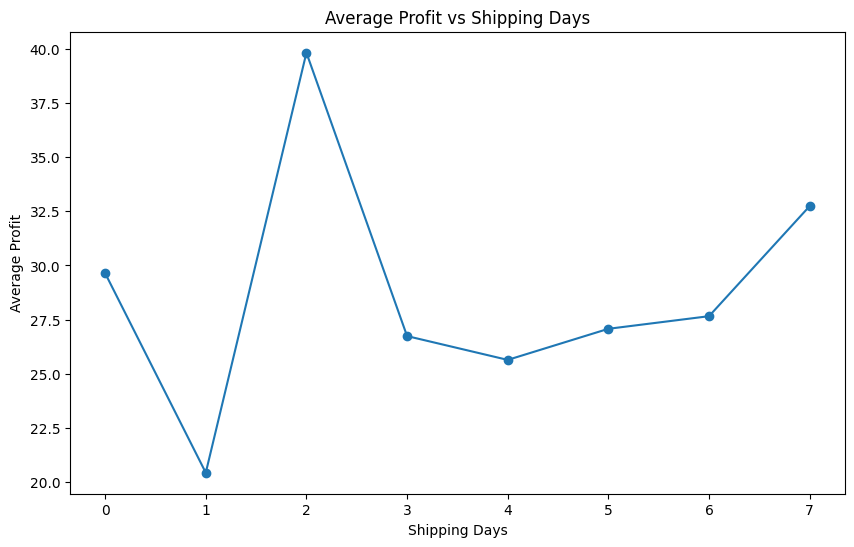

In [44]:
#Shipping Days vs Profit
shipping_profit = (
    df.groupby("Shipping_Days")["Profit"]
    .mean()
)

print(shipping_profit)

plt.figure(figsize=(10, 6))

shipping_profit.plot(kind="line", marker="o")

plt.title("Average Profit vs Shipping Days")
plt.xlabel("Shipping Days")
plt.ylabel("Average Profit")

plt.show()

                  Sales  Quantity  Discount    Profit  Shipping_Days  \
Sales          1.000000  0.200795 -0.028190  0.479064      -0.007354   
Quantity       0.200795  1.000000  0.008623  0.066253       0.018298   
Discount      -0.028190  0.008623  1.000000 -0.219487       0.000408   
Profit         0.479064  0.066253 -0.219487  1.000000      -0.004649   
Shipping_Days -0.007354  0.018298  0.000408 -0.004649       1.000000   
Profit_Margin  0.003444 -0.005280 -0.864452  0.223732      -0.011815   

               Profit_Margin  
Sales               0.003444  
Quantity           -0.005280  
Discount           -0.864452  
Profit              0.223732  
Shipping_Days      -0.011815  
Profit_Margin       1.000000  


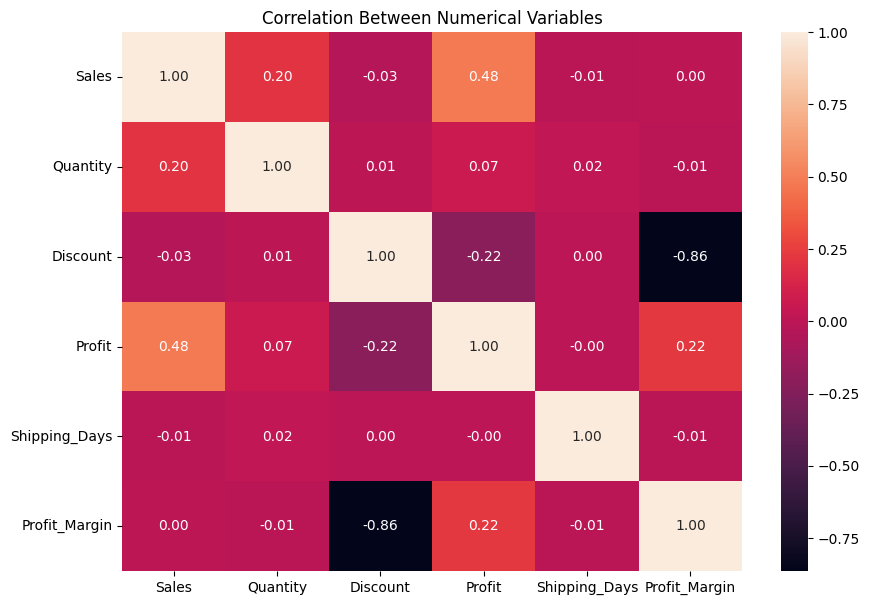

In [45]:
#CORRELATION ANALYSIS
numeric_columns = [
    "Sales",
    "Quantity",
    "Discount",
    "Profit",
    "Shipping_Days",
    "Profit_Margin"
]

correlation = df[numeric_columns].corr()

print(correlation)

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Between Numerical Variables")

plt.show()

# **Business Insights**

In [46]:
#BUSUNESS KPI
insights = {
    "Total Sales": df["Sales"].sum(),
    "Total Profit": df["Profit"].sum(),
    "Total Orders": df["Order ID"].nunique(),
    "Total Customers": df["Customer ID"].nunique(),
    "Average Order Value": df["Sales"].sum() / df["Order ID"].nunique()
}

for key, value in insights.items():
    print(f"{key}: {value:,.2f}")

Total Sales: 2,297,200.86
Total Profit: 286,397.02
Total Orders: 5,009.00
Total Customers: 793.00
Average Order Value: 458.61


Insight:

Total Sales: 2,297,200.86

Total Profit: 286,397.02

Total Orders: 5,009.00

Total Customers: 793.00

Average Order Value: 458.61

In [47]:
#Best-performing category
category_sales = df.groupby("Category")["Sales"].sum()
category_profit = df.groupby("Category")["Profit"].sum()

print("Highest Sales Category:")
print(category_sales.idxmax(), category_sales.max())

print("\nHighest Profit Category:")
print(category_profit.idxmax(), category_profit.max())

Highest Sales Category:
Technology 836154.033

Highest Profit Category:
Technology 145454.9481


Insight: The **Technology** category generated the highest sales, while **Technology** generated the highest profit.

In [48]:
#MOST PROFITABLE REGION
region_profit = df.groupby("Region")["Profit"].sum()

print("Most Profitable Region:")
print(region_profit.idxmax(), region_profit.max())

Most Profitable Region:
West 108418.4489


Insight: The **West** region generated the highest total profit, indicating stronger regional performance.

In [49]:
#LOSS MAKING PRODUCTS
product_profit = df.groupby("Product Name")["Profit"].sum()

loss_products = product_profit[product_profit < 0].sort_values()

print(loss_products.head(10))

Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: Profit, dtype: float64


Insight: The highest loss making product is **Cubify CubeX 3D Printer Double Head Print**

In [50]:
#DISCOUNT AND PROFIT
df[["Discount", "Profit"]].corr()

,Discount,Profit
Discount,1.000000,-0.219487
Profit,-0.219487,1.000000


In [51]:
#SALES TREND
yearly_sales = df.groupby("Year")["Sales"].sum()

print(yearly_sales)

Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64


Insight: Sales **decreased** from **2014 to 2015**, **then increased from 2015 to 2017** ,indicating a **variant** trend over the analyzed period.

In [53]:
#BEST CONSUMER SEGMENT

consumer_segment = df.groupby("Segment")["Profit"].sum()

print("MOST PROFITABLE CONSUMER SEGMENT:")
print(consumer_segment.idxmax(), consumer_segment.max())



MOST PROFITABLE CONSUMER SEGMENT:
Consumer 1161401.345


Insight: The **consumer** segment makes maximum profit

In [54]:
#SQL READY COLUMN NAMES
sql_columns = {
    "Row ID": "row_id",
    "Order ID": "order_id",
    "Order Date": "order_date",
    "Ship Date": "ship_date",
    "Ship Mode": "ship_mode",
    "Customer ID": "customer_id",
    "Customer Name": "customer_name",
    "Segment": "segment",
    "Country": "country",
    "City": "city",
    "State": "state",
    "Postal Code": "postal_code",
    "Region": "region",
    "Product ID": "product_id",
    "Category": "category",
    "Sub-Category": "sub_category",
    "Product Name": "product_name",
    "Sales": "sales",
    "Quantity": "quantity",
    "Discount": "discount",
    "Profit": "profit",
    "Year": "year",
    "Month": "month",
    "Month_Name": "month_name",
    "Quarter": "quarter",
    "Day_of_Week": "day_of_week",
    "Is_Weekend": "is_weekend",
    "Profit_Margin": "profit_margin"
}

df_sql = df.rename(columns=sql_columns)

df_sql.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,discount,profit,year,month,month_name,quarter,day_of_week,is_weekend,profit_margin,Shipping_Days
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,0.00,41.9136,2016,11,<bound method PandasDelegate._add_delegate_acc...,4,Tuesday,False,16.00,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,0.00,219.5820,2016,11,<bound method PandasDelegate._add_delegate_acc...,4,Tuesday,False,30.00,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,0.00,6.8714,2016,6,<bound method PandasDelegate._add_delegate_acc...,2,Sunday,True,47.00,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,0.45,-383.0310,2015,10,<bound method PandasDelegate._add_delegate_acc...,4,Sunday,True,-40.00,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,0.20,2.5164,2015,10,<bound method PandasDelegate._add_delegate_acc...,4,Sunday,True,11.25,7


In [55]:
df_sql.to_csv(
    "/content/Superstore_SQL_Ready.csv",
    index=False
)

In [56]:
print("Shape:", df_sql.shape)
print("Number of columns:", len(df_sql.columns))
print(df_sql.columns.tolist())

Shape: (9994, 29)
Number of columns: 29
['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit', 'year', 'month', 'month_name', 'quarter', 'day_of_week', 'is_weekend', 'profit_margin', 'Shipping_Days']


In [57]:
import pandas as pd

csv_check = pd.read_csv("/content/Superstore_SQL_Ready.csv")

print("Rows:", csv_check.shape[0])
print("Columns:", csv_check.shape[1])

for i, col in enumerate(csv_check.columns, start=1):
    print(i, col)

Rows: 9994
Columns: 29
1 row_id
2 order_id
3 order_date
4 ship_date
5 ship_mode
6 customer_id
7 customer_name
8 segment
9 country
10 city
11 state
12 postal_code
13 region
14 product_id
15 category
16 sub_category
17 product_name
18 sales
19 quantity
20 discount
21 profit
22 year
23 month
24 month_name
25 quarter
26 day_of_week
27 is_weekend
28 profit_margin
29 Shipping_Days


In [59]:
csv_check = csv_check.rename(columns={
    "Shipping_Days": "shipping_days"
})

print(csv_check.columns.tolist())

['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit', 'year', 'month', 'month_name', 'quarter', 'day_of_week', 'is_weekend', 'profit_margin', 'shipping_days']


In [61]:
csv_check.to_csv(
    "/content/Superstore_SQL_Ready.csv",
    index=False,
    encoding="utf-8"
)

In [63]:
from google.colab import files

files.download("/content/Superstore_SQL_Ready.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [64]:
# Create a copy of your dataframe
df_sql = df.copy()

# Remove Shipping_Days from the CSV
df_sql = df_sql.drop(columns=["Shipping_Days"])

# Rename columns to PostgreSQL-friendly names
df_sql.columns = [
    "row_id",
    "order_id",
    "order_date",
    "ship_date",
    "ship_mode",
    "customer_id",
    "customer_name",
    "segment",
    "country",
    "city",
    "state",
    "postal_code",
    "region",
    "product_id",
    "category",
    "sub_category",
    "product_name",
    "sales",
    "quantity",
    "discount",
    "profit",
    "year",
    "month",
    "quarter",
    "day_of_week",
    "is_weekend",
    "profit_margin"
]

print("Shape:", df_sql.shape)
print(df_sql.columns.tolist())

Shape: (9994, 28)
['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit', 'year', 'month', 'month_name', 'quarter', 'day_of_week', 'is_weekend', 'profit_margin']


In [66]:
df_sql.to_csv(
    "/content/Superstore_SQL_Ready_28.csv",
    index=False,
    encoding="utf-8"
)

from google.colab import files

files.download("/content/Superstore_SQL_Ready_28.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [77]:


print("Shape:", df_sql.shape)
print(df_sql.columns.tolist())

df_sql.to_csv(
    "/content/Superstore_SQL_Ready_27.csv",
    index=False,
    encoding="utf-8"
)

from google.colab import files





Shape: (9994, 27)
['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit', 'year', 'month', 'quarter', 'day_of_week', 'is_weekend', 'profit_margin']
